In [244]:
import numpy as np
import pandas as pd
import re

In [245]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [246]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [247]:
df.duplicated().sum()

np.int64(123)

In [248]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 15,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,1.0,NaN,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Icici bank ATM', 'Ahmed Hospital Multi Speciality', 'Dayal Eye & Maternity Centre', 'Kalyani Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Dr. Sandeep Chauhan', 'Ahooja Eye and Dental Institute Hospital', 'Aarvy Hospital', 'Lotus Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Dental Health Centre', 'Pushpanjali Hospital', 'Gupta Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Thakral Nursing and Maternity Home', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'Lall Eye Care Centre', 'M Goel Hospital', 'Shivam Hospital Gurgaon', 'Dentecare - Multispeciality Dental Clinic', 'Jackson Hospital', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Gardian Pharmacy', 'Indian Oil', 'IBP Petrol Pump', 'IBP Petrol Station', 'Indian Oil', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Darbar', '32nd Milestone', 'Cafe Coffee Day', 'Bar and restaurant', 'Om Sweets', 'Fast Food', 'Fast food', 'govt sec school', 'Salvan Public School', 'District library gurgaon']",NaN,['Water Storage']


## 1. areaWithType

In [249]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3123,1.17,1671.0,Super Built up area 1671(155.24 sq.m.)Built Up area: 1660 sq.ft. (154.22 sq.m.)Carpet area: 1650 sq.ft. (153.29 sq.m.)
2656,3.50,1800.0,Carpet area: 1800 (167.23 sq.m.)
2943,10.45,3240.0,Plot area 360(301.01 sq.m.)
2181,1.27,1763.0,Super Built up area 1763(163.79 sq.m.)Carpet area: 1410 sq.ft. (130.99 sq.m.)
2450,1.16,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq.ft. (92.16 sq.m.)


In [250]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [251]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [252]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [253]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [254]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
402,4.50,house,4950.0,Plot area 550(459.87 sq.m.),NaN,NaN,NaN
2173,1.55,flat,1920.0,Super Built up area 1920(178.37 sq.m.),1920.0,NaN,NaN
2707,1.50,flat,1276.0,Super Built up area 1276(118.54 sq.m.),1276.0,NaN,NaN
2897,1.15,flat,2091.0,Built Up area: 2000 (185.81 sq.m.),NaN,2000.0,NaN
2547,1.35,flat,1400.0,Super Built up area 1500(139.35 sq.m.)Built Up area: 1450 sq.ft. (134.71 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),1500.0,1450.0,1400.0


In [255]:
df.duplicated().sum()

np.int64(123)

In [256]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(535, 7)

In [257]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,1.07,house,900.0,Plot area 900(83.61 sq.m.),NaN,NaN,NaN
4,1.00,house,135.0,Plot area 135(12.54 sq.m.)Built Up area: 3750 sq.ft. (348.39 sq.m.),NaN,3750.0,NaN
5,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
9,18.50,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,NaN,NaN
14,1.10,house,1782.0,Plot area 1782(165.55 sq.m.),NaN,NaN,NaN


In [258]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                147
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [259]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [260]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,1.07,house,900.0,Plot area 900(83.61 sq.m.),NaN,NaN,NaN
5,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
9,18.50,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,NaN,NaN
14,1.10,house,1782.0,Plot area 1782(165.55 sq.m.),NaN,NaN,NaN
18,8.50,house,3132.0,Plot area 348(290.97 sq.m.),NaN,NaN,NaN


In [261]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [262]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [263]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [264]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,1.07,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
5,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
9,18.50,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,7000.00,NaN
14,1.10,house,1782.0,Plot area 1782(165.55 sq.m.),NaN,1782.00,NaN
18,8.50,house,3132.0,Plot area 348(290.97 sq.m.),NaN,348.00,NaN
21,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
25,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
28,7.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
29,0.65,house,585.0,Plot area 65(54.35 sq.m.),NaN,65.00,NaN
30,1.44,house,540.0,Plot area 60(50.17 sq.m.),NaN,60.00,NaN


In [265]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [266]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [267]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,1.07,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
5,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
9,18.50,house,7000.0,Plot area 7000(650.32 sq.m.),NaN,7000.00,NaN
14,1.10,house,1782.0,Plot area 1782(165.55 sq.m.),NaN,1782.00,NaN
18,8.50,house,3132.0,Plot area 348(290.97 sq.m.),NaN,3132.00,NaN
21,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
25,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
28,7.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
29,0.65,house,585.0,Plot area 65(54.35 sq.m.),NaN,585.00,NaN
30,1.44,house,540.0,Plot area 60(50.17 sq.m.),NaN,540.00,NaN


In [268]:
# update the original dataframe
df.update(all_nan_df)

In [269]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                147
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [270]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,independent,sector 15,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,1.0,NaN,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Icici bank ATM', 'Ahmed Hospital Multi Speciality', 'Dayal Eye & Maternity Centre', 'Kalyani Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Dr. Sandeep Chauhan', 'Ahooja Eye and Dental Institute Hospital', 'Aarvy Hospital', 'Lotus Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Dental Health Centre', 'Pushpanjali Hospital', 'Gupta Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Thakral Nursing and Maternity Home', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'Lall Eye Care Centre', 'M Goel Hospital', 'Shivam Hospital Gurgaon', 'Dentecare - Multispeciality Dental Clinic', 'Jackson Hospital', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Gardian Pharmacy', 'Indian Oil', 'IBP Petrol Pump', 'IBP Petrol Station', 'Indian Oil', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Darbar', '32nd Milestone', 'Cafe Coffee Day', 'Bar and restaurant', 'Om Sweets', 'Fast Food', 'Fast food', 'govt sec school', 'Salvan Public School', 'District library gurgaon']",NaN,['Water Storage'],NaN,900.0,NaN
1,flat,ats tourmaline,sector 109,1.75,8139.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,servant room,9.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2150.0,NaN,NaN
2,flat,paras dews,sector 106,1.40,9978.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up area: 1535 sq.ft. (142.61 sq.m.)Carpet area: 1403 sq.ft. (130.34 sq.m.),4,6,3+,servant room,10.0,North-West,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']",NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2355.0,1535.0,1403.0
3,flat,paras dews,sector 106,1.10,9734.0,1130.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),3,4,3+,servant room,8.0,North-West,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka

## 2.additionalRoom

In [271]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      706
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
pooja room,st

In [272]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [273]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1163,not available,0,0,0,0,0
3644,servant room,0,1,0,0,0
3327,"pooja room,study room,servant room,store room",1,1,1,1,0
752,not available,0,0,0,0,0
1700,not available,0,0,0,0,0


In [274]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 15,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,1.0,NaN,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Icici bank ATM', 'Ahmed Hospital Multi Speciality', 'Dayal Eye & Maternity Centre', 'Kalyani Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Dr. Sandeep Chauhan', 'Ahooja Eye and Dental Institute Hospital', 'Aarvy Hospital', 'Lotus Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Dental Health Centre', 'Pushpanjali Hospital', 'Gupta Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Thakral Nursing and Maternity Home', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'Lall Eye Care Centre', 'M Goel Hospital', 'Shivam Hospital Gurgaon', 'Dentecare - Multispeciality Dental Clinic', 'Jackson Hospital', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Gardian Pharmacy', 'Indian Oil', 'IBP Petrol Pump', 'IBP Petrol Station', 'Indian Oil', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Darbar', '32nd Milestone', 'Cafe Coffee Day', 'Bar and restaurant', 'Om Sweets', 'Fast Food', 'Fast food', 'govt sec school', 'Salvan Public School', 'District library gurgaon']",NaN,['Water Storage'],NaN,900.0,NaN,0,1,0,0,0
1,flat,ats tourmaline,sector 109,1.75,8139.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,servant room,9.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2150.0,NaN,NaN,0,1,0,0,0
2,flat,paras dews,sector 106,1.40,9978.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up area: 1535 sq.ft. (142.61 sq.m.)Carpet area: 1403 sq.ft. (130.34 sq.m.),4,6,3+,servant room,10.0,North-West,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']",NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2355.0,1535.0,1403.0,0,1,0,0,0
3,flat,paras dews,sector 106,1.10,9734.0,1130.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),3,4,3+,servant room,8.0,North

## 3.agePossession

In [275]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1677
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  20
By 2023                 19
By 2024                 17
Dec-24                  15
Mar-24                  14
Aug-23                   7
Jan-24                   7
Dec-25                   7
Oct-24                   7
Jun-24                   5
Nov-23                   5
By 2025                  4
Aug-24                   4
Sep-23                   4
Jul-24                   4
Nov-24                   3
Oct-23                   3
May-24                   3
Feb-24                   3
Jan-25                   3
Jun 2024                 2
By 2027                  2
Sep-25                   2
Jul-25                   2
Dec-26                   2
Jan-26                   2
Jul-27                   2
Apr-26                   2
Mar-25        

In [276]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [277]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [278]:
df['agePossession'].value_counts()

agePossession
Relatively New        1677
New Property           626
Moderately Old         575
Undefined              476
Old Property           310
Under Construction     140
Name: count, dtype: int64

In [279]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,independent,sector 15,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,1.0,NaN,Old Property,"['Hanuman Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Icici bank ATM', 'Ahmed Hospital Multi Speciality', 'Dayal Eye & Maternity Centre', 'Kalyani Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Dr. Sandeep Chauhan', 'Ahooja Eye and Dental Institute Hospital', 'Aarvy Hospital', 'Lotus Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Dental Health Centre', 'Pushpanjali Hospital', 'Gupta Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Thakral Nursing and Maternity Home', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'Lall Eye Care Centre', 'M Goel Hospital', 'Shivam Hospital Gurgaon', 'Dentecare - Multispeciality Dental Clinic', 'Jackson Hospital', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Gardian Pharmacy', 'Indian Oil', 'IBP Petrol Pump', 'IBP Petrol Station', 'Indian Oil', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Darbar', '32nd Milestone', 'Cafe Coffee Day', 'Bar and restaurant', 'Om Sweets', 'Fast Food', 'Fast food', 'govt sec school', 'Salvan Public School', 'District library gurgaon']",NaN,['Water Storage'],NaN,900.0,NaN,0,1,0,0,0
1,flat,ats tourmaline,sector 109,1.75,8139.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,servant room,9.0,North-East,Relatively New,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2150.0,NaN,NaN,0,1,0,0,0
2,flat,paras dews,sector 106,1.40,9978.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up area: 1535 sq.ft. (142.61 sq.m.)Carpet area: 1403 sq.ft. (130.34 sq.m.),4,6,3+,servant room,10.0,North-West,Relatively New,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']",NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2355.0,1535.0,1403.0,0,1,0,0,0
3,flat,paras dews,sector 106,1.10,9734.0,1130.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),3,4,3+,servant room,8.0,North-W

## 4.furnishDetails

In [280]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1003,NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
2893,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
3035,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
1889,"['4 Wardrobe', '5 Fan', '4 Geyser', '2 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'Park', 'Natural Light', 'Airy Rooms', 'Club house / Community Center']"
1614,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Swimming Pool', 'Park', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"


In [281]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


In [282]:
furnishings_df.shape

(3804, 19)

In [283]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22632\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [284]:
furnishings_df.sample(5)

,AC,Fridge,Dining Table,Modular Kitchen,Sofa,Light,Chimney,Fan,Curtains,Stove,Microwave,Washing Machine,Bed,Water Purifier,TV,Geyser,Wardrobe,Exhaust Fan
848,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1858,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
604,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3767,7,0,0,1,0,6,1,11,1,1,0,0,0,0,0,5,5,1
3567,12,0,0,0,0,26,1,6,1,0,0,0,0,0,0,4,4,1


In [285]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [286]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [287]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

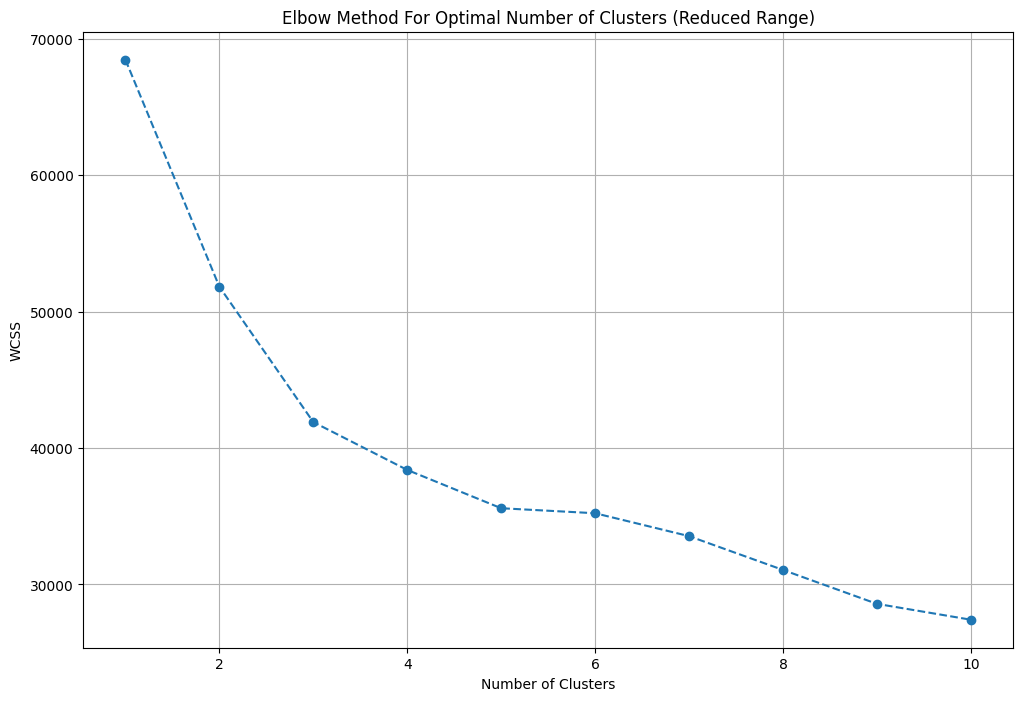

In [288]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [289]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [290]:
df = df.iloc[:,:-18]

In [291]:
df['furnishing_type'] = cluster_assignments

In [292]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
392,NaN,0
1799,"['1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3203,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
2087,"['2 Geyser', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
489,"['5 Fan', '1 Exhaust Fan', '5 Geyser', '18 Light', '1 AC', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', '1 Microwave', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1


## 5.features

In [293]:
df[['society','features']].sample(5)

,society,features
1753,signature signum a,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
1527,la vida by tata housing,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2076,ansals palam vihar,"['Private Garden / Terrace', 'Maintenance Staff']"
2129,aipl the peaceful homes,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
2251,independent,NaN


In [294]:
df['features'].isnull().sum()

np.int64(635)

In [295]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [296]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [297]:
temp_df = df[df['features'].isnull()]

In [298]:
temp_df.shape

(635, 26)

In [299]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [300]:
df.loc[temp_df.index,'features'] = x.values

In [301]:
df['features'].isnull().sum()

np.int64(506)

In [302]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [303]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [304]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Airy Rooms,Amphitheatre,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Billiards,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Toddler Pool,Valet Parking,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2716,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
785,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
865,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
217,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1273,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0


In [305]:
features_binary_df.shape

(3804, 122)

In [306]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

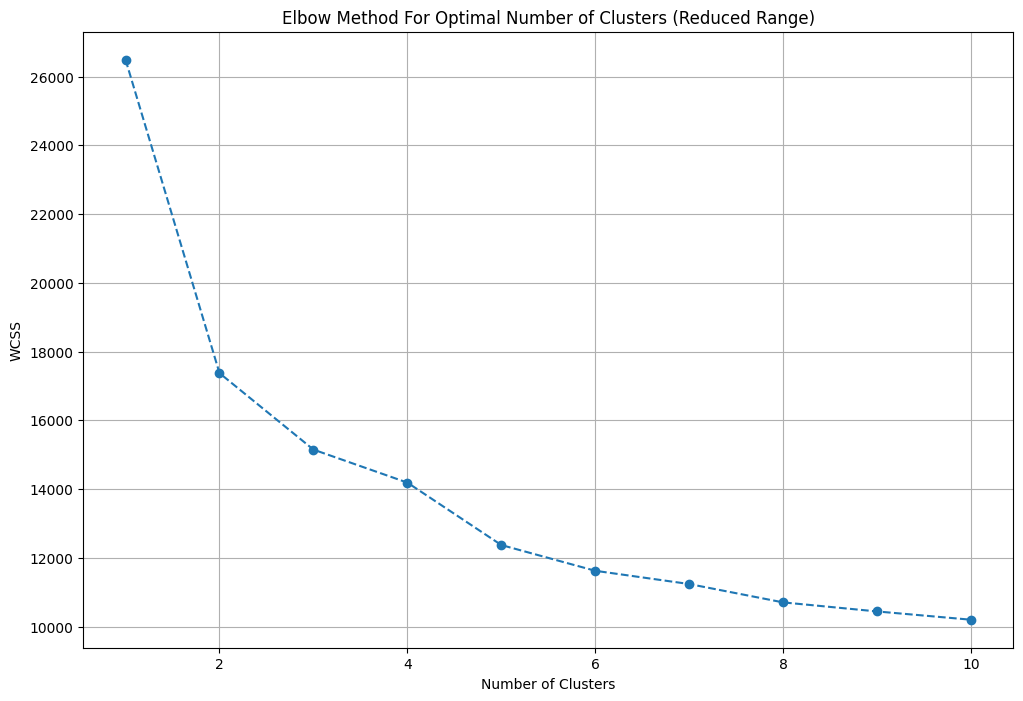

In [307]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [308]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}

for col in ['Bowling Alley','Party Lawn','Theatre']:
    if col not in features_binary_df.columns:
        features_binary_df[col] = 0
    
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [309]:
df['luxury_score'] = luxury_score


In [310]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 15,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,1.0,NaN,Old Property,"['Hanuman Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Icici bank ATM', 'Ahmed Hospital Multi Speciality', 'Dayal Eye & Maternity Centre', 'Kalyani Hospital Gurgaon', 'Saraswati Hospital Gurgaon', 'Dr. Sandeep Chauhan', 'Ahooja Eye and Dental Institute Hospital', 'Aarvy Hospital', 'Lotus Hospital Gurgaon', 'Mamta Hospital Gurgaon', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Sharma Hospital Gurgaon', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Dental Health Centre', 'Pushpanjali Hospital', 'Gupta Hospital Gurgaon', 'Bansal Medicare and Maternity Centre', 'Pushpanjali Hospital Gurgaon', 'Thakral Nursing and Maternity Home', 'Lall Nursing and Maternity Home', 'Om Charitable Dental & Implant Centre', 'Lall Eye Care Centre', 'M Goel Hospital', 'Shivam Hospital Gurgaon', 'Dentecare - Multispeciality Dental Clinic', 'Jackson Hospital', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Gardian Pharmacy', 'Indian Oil', 'IBP Petrol Pump', 'IBP Petrol Station', 'Indian Oil', 'State bank of india sbi', 'Punjab national bank', 'Rang Parivartan', 'Darbar', '32nd Milestone', 'Cafe Coffee Day', 'Bar and restaurant', 'Om Sweets', 'Fast Food', 'Fast food', 'govt sec school', 'Salvan Public School', 'District library gurgaon']",NaN,['Water Storage'],NaN,900.0,NaN,0,1,0,0,0,0,[Water Storage],7
1,flat,ats tourmaline,sector 109,1.75,8139.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,servant room,9.0,North-East,Relatively New,"['Dwarka Sector 21 Metro Station', 'NeoSquare Mall', 'Dwarka Expressway', 'Euro International School', 'The NorthCap University', 'Metro Hospital, Palam Vihar', 'Indira Gandhi International Airport', 'Accenture DDC5', 'Hyatt Place Gurgaon Udyog Vihar', 'Hamoni Golf Camp', 'Nehru Stadium']",[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",2150.0,NaN,NaN,0,1,0,0,0,0,"[Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Separate entry for servant room, No open drainage around, Visitor Parking, Swimming Pool, Park, Internet/wi-fi connectivity, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center, Water softening plant]",94
2,flat,paras dews,sector 106,1.40,9978.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up area: 1535 sq.ft. (142.61 sq.m.)Carpet area: 1403 sq.ft. (130.34 sq.m.),4,6,3+,servant room,10.0,North-West,Relatively New,"['MG Road Metro Station', 'NeoSquare Shopping Mall', 'Dwarka Expressway', 'Glorious World School', 'DPG Institute of Technology', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Gurgaon', 'Country Inn & Suites by Radisson', 'SkyJumper Trampoline Park', 'Hamoni Golf Camp']",NaN,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', '

In [311]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [312]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2045,flat,ramsons kshitij,sector 95,0.17,544.0,3125.0,Carpet area: 3212 (298.4 sq.m.),1,1,1,12.0,North-East,Relatively New,NaN,NaN,3212.0,0,0,0,0,0,0,56
3085,house,independent,sector 3,0.90,8928.0,1008.0,Built Up area: 1008 (93.65 sq.m.),3,1,0,1.0,NaN,Undefined,NaN,1008.0,NaN,0,0,0,0,0,0,0
469,flat,vatika gurgaon,sector 83,1.12,6455.0,1735.0,Super Built up area 1735(161.19 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,3,2,17.0,South,Moderately Old,1735.0,1500.0,1400.0,0,0,0,0,0,1,111
2414,flat,suncity vatsal valley,gwal pahari,1.53,10699.0,1430.0,Carpet area: 1430 (132.85 sq.m.),3,3,3,2.0,North-East,New Property,NaN,NaN,1430.0,0,0,0,0,0,1,117
3798,flat,cghs vidya enclave,sector 56,1.70,10967.0,1550.0,Super Built up area 1600(148.64 sq.m.)Carpet area: 1550 sq.ft. (144 sq.m.),3,2,3,6.0,NaN,Old Property,1600.0,NaN,1550.0,0,0,1,0,0,0,101


In [313]:
df.shape

(3804, 23)

In [314]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)